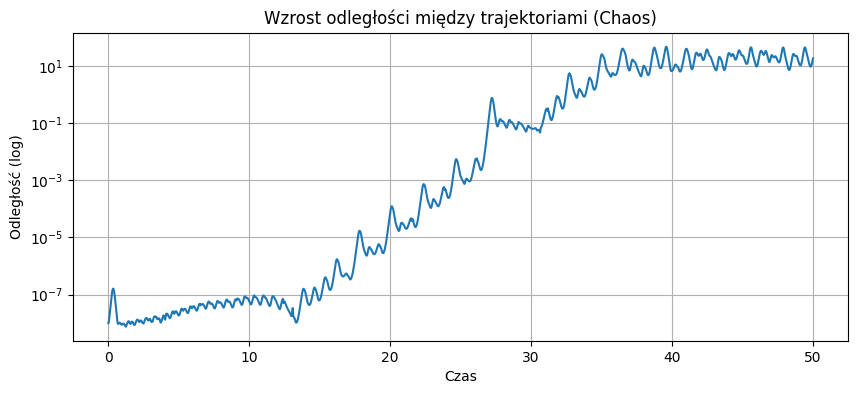

Oszacowany największy wykładnik Lapunowa: 0.244


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def lorenz(t, state):
    x, y, z = state
    return [10*(y-x), x*(28-z)-y, x*y-(8/3)*z]

t_eval = np.linspace(0, 50, 5000)
# Startujemy z dwóch punktów różniących się o 1e-8
sol1 = solve_ivp(lorenz, (0, 50), [1, 1, 1], t_eval=t_eval)
sol2 = solve_ivp(lorenz, (0, 50), [1, 1+1e-8, 1], t_eval=t_eval)

# Odległość między trajektoriami
dist = np.linalg.norm(sol1.y - sol2.y, axis=0)

plt.figure(figsize=(10, 4))
plt.semilogy(t_eval, dist) # Skala logarytmiczna!
plt.title("Wzrost odległości między trajektoriami (Chaos)")
plt.xlabel("Czas"); plt.ylabel("Odległość (log)")
plt.grid(True)
plt.show()

# Oszacowanie wykładnika: nachylenie linii na wykresie log
log_dist = np.log(dist[100:1000]) # bierzemy początkowy wzrost
t_part = t_eval[100:1000]
lambda_est = np.polyfit(t_part, log_dist, 1)[0]
print(f"Oszacowany największy wykładnik Lapunowa: {lambda_est:.3f}")

In [7]:
import sympy as sp

x1, x2 = sp.symbols('x1 x2')
f1 = x1**2 - 2*x1
f2 = 1/x2 - x1 + 1

# Macierz Jacobiego
J = sp.Matrix([f1, f2]).jacobian([x1, x2])
P = {x1: 2, x2: 1}
J_at_P = J.subs(P)

print("Macierz Jacobiego w punkcie (2, 1):")
sp.pprint(J_at_P)
eigenvals = J_at_P.eigenvals()
print(f"Wartości własne: {list(eigenvals.keys())}")

Macierz Jacobiego w punkcie (2, 1):
⎡2   0 ⎤
⎢      ⎥
⎣-1  -1⎦
Wartości własne: [2, -1]


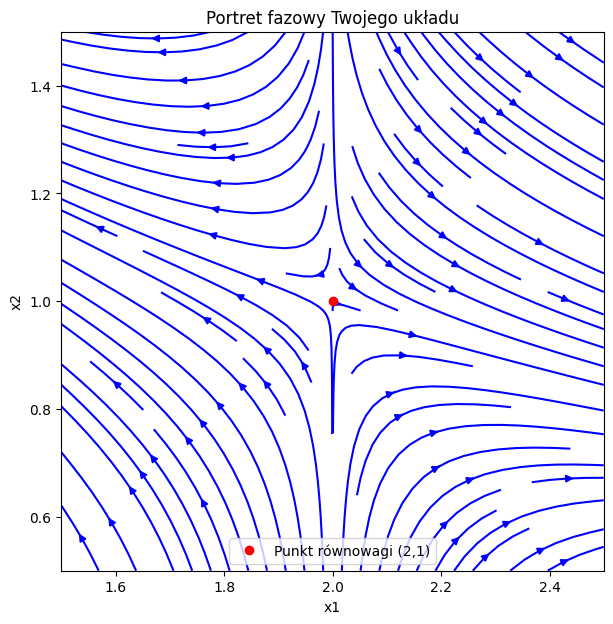

In [8]:
def system(t, state):
    x1, x2 = state
    # Uwaga: dodajemy małe zabezpieczenie przed x2=0
    return [x1**2 - 2*x1, 1/x2 - x1 + 1]

y, x = np.mgrid[0.5:1.5:20j, 1.5:2.5:20j]
u, v = x**2 - 2*x, 1/y - x + 1

plt.figure(figsize=(7, 7))
plt.streamplot(x, y, u, v, color='blue')
plt.plot(2, 1, 'ro', label='Punkt równowagi (2,1)')
plt.title("Portret fazowy Twojego układu")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend(); plt.show()

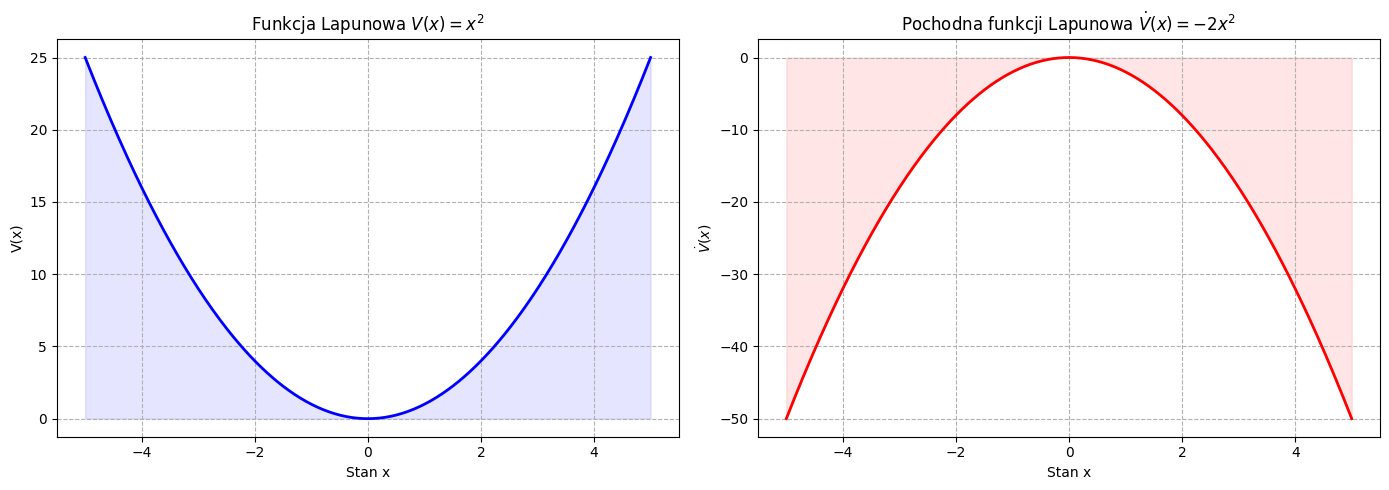

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Definicja zakresu x
x = np.linspace(-5, 5, 400)

# Funkcja Lapunowa i jej pochodna
V = x**2
V_dot = -2 * x**2

# Tworzenie wykresów
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Wykres V(x)
ax1.plot(x, V, color='blue', linewidth=2)
ax1.fill_between(x, V, color='blue', alpha=0.1)
ax1.set_title(r'Funkcja Lapunowa $V(x) = x^2$')
ax1.set_xlabel('Stan x')
ax1.set_ylabel('V(x)')
ax1.grid(True, linestyle='--')

# Wykres V_dot(x)
ax2.plot(x, V_dot, color='red', linewidth=2)
ax2.fill_between(x, V_dot, color='red', alpha=0.1)
ax2.set_title(r'Pochodna funkcji Lapunowa $\dot{V}(x) = -2x^2$')
ax2.set_xlabel('Stan x')
ax2.set_ylabel(r'$\dot{V}(x)$')
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

1. Teoria i obliczenia (Logika metody)Mamy dany model: $\dot{x} = -x$ oraz proponowaną funkcję Lapunowa: $V(x) = x^2$.Aby układ był stabilny w sensie Lapunowa, muszą zostać spełnione warunki:$V(x)$ musi być dodatnio określona: $V(0) = 0$ oraz $V(x) > 0$ dla $x \neq 0$.U nas: $0^2 = 0$ oraz $x^2$ zawsze daje wynik dodatni. Warunek spełniony.Pochodna funkcji Lapunowa $\dot{V}(x)$ musi być ujemnie określona (dla stabilności asymptotycznej).Obliczamy pochodną $\dot{V}(x)$ korzystając z reguły łańcuchowej:$$\dot{V}(x) = \frac{dV}{dx} \cdot \frac{dx}{dt}$$$\frac{dV}{dx} = 2x$ (pochodna $x^2$)$\frac{dx}{dt} = -x$ (podstawiamy z naszego modelu)Zatem:$$\dot{V}(x) = 2x \cdot (-x) = -2x^2$$Wniosek: Ponieważ $\dot{V}(x) = -2x^2$ jest zawsze mniejsza od zera dla każdego $x \neq 0$, układ jest asymptotycznie stabilny. Oznacza to, że niezależnie od tego, gdzie zaczniemy, układ 

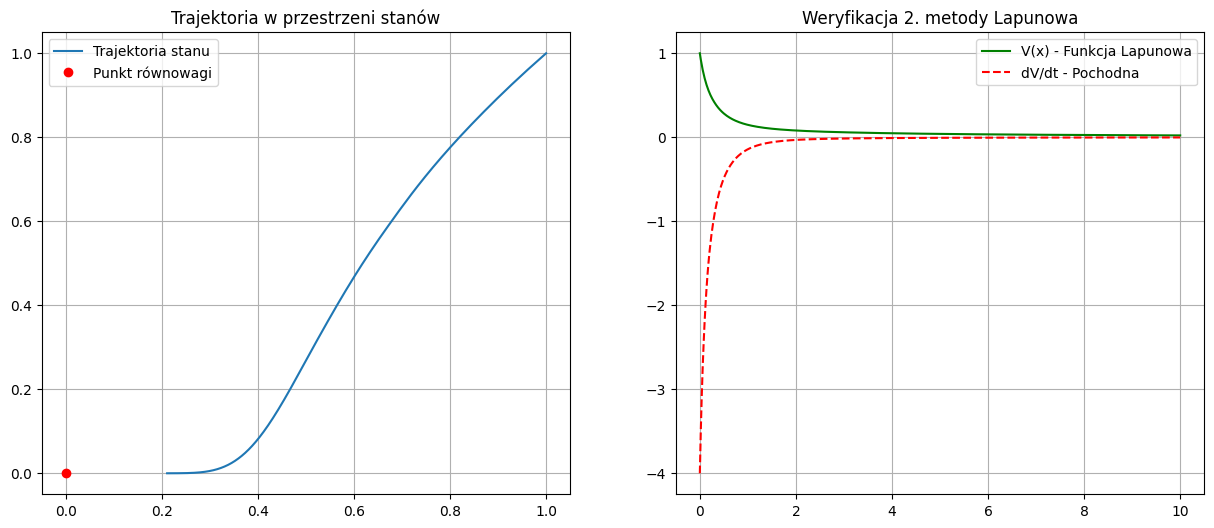

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Definicja dynamiki układu
def system(t, x):
    x1, x2 = x
    # Równania różniczkowe nieliniowe
    dx1_dt = -x1**3 - x1 * x2**2
    dx2_dt = -x2 - x2 * x1**2
    return [dx1_dt, dx2_dt]

# 2. Parametry symulacji
t_span = (0, 10)
x0 = [1.0, 1.0] # Warunek początkowy (Zadanie Cauchy'ego)
sol = solve_ivp(system, t_span, x0, t_eval=np.linspace(0, 10, 500))

# 3. Analiza metodą Lapunowa
# V = 0.5 * (x1^2 + x2^2)
V = 0.5 * (sol.y[0]**2 + sol.y[1]**2)
# dV/dt (wyliczone analitycznie powyżej)
V_dot = -sol.y[0]**4 - 2*(sol.y[0]**2)*(sol.y[1]**2) - sol.y[1]**2

# Wykresy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Trajektoria: pokazuje, że stan dąży do (0,0)
ax1.plot(sol.y[0], sol.y[1], label='Trajektoria stanu')
ax1.plot(0, 0, 'ro', label='Punkt równowagi')
ax1.set_title('Trajektoria w przestrzeni stanów')
ax1.grid(True); ax1.legend()

# Funkcja Lapunowa: pokazuje, że "energia" stale maleje (dV/dt < 0)
ax2.plot(sol.t, V, 'g', label='V(x) - Funkcja Lapunowa')
ax2.plot(sol.t, V_dot, 'r--', label='dV/dt - Pochodna')
ax2.set_title('Weryfikacja 2. metody Lapunowa')
ax2.grid(True); ax2.legend()

plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\stanislaw.krupa\AppData\Local\Temp\ipykernel_34136\2978146847.py:15: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Stabilność układu $\dot{x} = -x^3$")


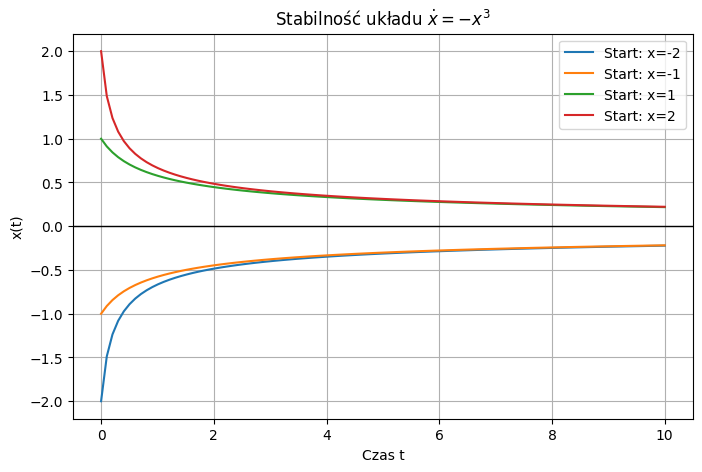

In [2]:
from scipy.integrate import odeint

def system(x, t):
    return -x**3

t = np.linspace(0, 10, 100)
x0_values = [-2, -1, 1, 2]

plt.figure(figsize=(8, 5))
for x0 in x0_values:
    sol = odeint(system, x0, t)
    plt.plot(t, sol, label=f'Start: x={x0}')

plt.axhline(0, color='black', lw=1)
plt.title("Stabilność układu $\dot{x} = -x^3$")
plt.xlabel("Czas t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

Analiza punktów równowagi:
Punkt (0, -1): Wartości własne = [-1. -2.], Stan = Stabilny
Punkt (2, 1): Wartości własne = [-1.  2.], Stan = Niestabilny


TypeError: streamplot() got an unexpected keyword argument 'alpha'

<Figure size 1000x800 with 0 Axes>

In [4]:
import numpy as np

def lyapunov_exponent(x1_0, x2_0, dt=0.01, n_steps=10000):
    # Parametry początkowe i małe zaburzenie
    x = np.array([x1_0, x2_0])
    d0 = 1e-8
    x_perturbed = x + np.array([d0, 0])
    
    lyap_sum = 0
    
    for _ in range(n_steps):
        # Ewolucja obu punktów (metoda Eulera dla uproszczenia)
        def f(v):
            return np.array([v[0]**2 - 2*v[0], 1/v[1] - v[0] + 1])
        
        x = x + f(x) * dt
        x_perturbed = x_perturbed + f(x_perturbed) * dt
        
        # Nowa odległość
        d1 = np.linalg.norm(x - x_perturbed)
        
        # Akumulacja wykładnika i normalizacja odległości
        lyap_sum += np.log(d1 / d0)
        x_perturbed = x + (x_perturbed - x) * (d0 / d1)
        
    return lyap_sum / (n_steps * dt)

# Przykład dla okolic punktu (2, 1)
print(f"Szacowany wykładnik Lapunowa: {lyapunov_exponent(2.1, 1.1):.4f}")

Szacowany wykładnik Lapunowa: nan


C:\Users\stanislaw.krupa\AppData\Local\Temp\ipykernel_34136\968491578.py:23: RuntimeWarning: divide by zero encountered in log
  lyap_sum += np.log(d1 / d0)
C:\Users\stanislaw.krupa\AppData\Local\Temp\ipykernel_34136\968491578.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  x_perturbed = x + (x_perturbed - x) * (d0 / d1)
C:\Users\stanislaw.krupa\AppData\Local\Temp\ipykernel_34136\968491578.py:24: RuntimeWarning: invalid value encountered in multiply
  x_perturbed = x + (x_perturbed - x) * (d0 / d1)
C:\Users\stanislaw.krupa\AppData\Local\Temp\ipykernel_34136\968491578.py:14: RuntimeWarning: overflow encountered in scalar power
  return np.array([v[0]**2 - 2*v[0], 1/v[1] - v[0] + 1])
C:\Users\stanislaw.krupa\AppData\Local\Temp\ipykernel_34136\968491578.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  return np.array([v[0]**2 - 2*v[0], 1/v[1] - v[0] + 1])
